# **MÓDULO 35 - Cross Validation**

Nesta tarefa, você trabalhará com uma base de dados que contém informações sobre variáveis ambientais coletadas para a detecção de incêndios. O objetivo é utilizar técnicas de validação cruzada (cross-validation) para avaliar a performance de um modelo de classificação na previsão da ocorrência de um incêndio com base nas variáveis fornecidas.


Descrição da Base de Dados
A base de dados contém as seguintes variáveis:

Unnamed:0: Índice (não é uma variável útil para o modelo)

UTC: Tempo em Segundos UTC

Temperature[C]: Temperatura do Ar (em graus Celsius)

Humidity[%]: Umidade do Ar (em porcentagem)

TVOC[ppb]: Total de Compostos Orgânicos Voláteis (medido em partes por bilhão)

eCO2[ppm]: Concentração equivalente de CO2 (medido em partes por milhão)

Raw H2: Hidrogênio molecular bruto, não compensado

Raw Ethanol: Etanol gasoso bruto

Pressure[hPA]: Pressão do Ar (em hectopascais)

PM1.0: Material particulado de tamanho < 1,0 µm

PM2.5: Material particulado de tamanho >1,0 µm e < 2,5 µm

NC0.5: Concentração numérica de material particulado de tamanho < 0,5 µm

NC1.0: Concentração numérica de material particulado de tamanho 0,5 µm < 1,0 µm

NC2.5: Concentração numérica de material particulado de tamanho 1,0 µm < 2,5 µm

CNT: Contador de amostras


E a variável alvo:

Fire Alarm: Indicador binário de incêndio (1 se houver incêndio, 0 caso contrário)

O objetivo desta tarefa é aplicar a técnica de validação cruzada (cross-validation) para avaliar a performance de um modelo de classificação. A validação cruzada ajudará a garantir que o modelo seja avaliado de maneira robusta e generalize bem para dados não vistos.

In [44]:
# Biblioteca para arquivo

import os

# Biblioteca para dados

import pandas as pd
import numpy as np

# Biblioteca para visualização dos dados

import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# Biblioteca para pr-processamento

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from imblearn.over_sampling import SMOTE 
from sklearn.preprocessing import StandardScaler

# Biblioterca para ML

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Bibliotecas para métricas

from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

# 1 - Carregue a base de dados, verifique os tipos de dados e também se há presença de dados faltantes ou nulos.

- Carregando a base

In [45]:
# Verificando se o arquivo existe

path = ".\\smoke_detection_iot.csv"

try:
    os.path.exists(path)
    print("O arquivo foi encontrado!!! ")
except:
    print("O arquivo não foi encontrado...")

# Carregando Base

df = pd.read_csv(path)

# Verificando se deu certo

df.head(10)

O arquivo foi encontrado!!! 


,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
0,0,1654733331,20.000,57.36,0,400,12306,18520,939.735,0.0,0.00,0.0,0.000,0.00,0,0
1,1,1654733332,20.015,56.67,0,400,12345,18651,939.744,0.0,0.00,0.0,0.000,0.00,1,0
2,2,1654733333,20.029,55.96,0,400,12374,18764,939.738,0.0,0.00,0.0,0.000,0.00,2,0
3,3,1654733334,20.044,55.28,0,400,12390,18849,939.736,0.0,0.00,0.0,0.000,0.00,3,0
4,4,1654733335,20.059,54.69,0,400,12403,18921,939.744,0.0,0.00,0.0,0.000,0.00,4,0
5,5,1654733336,20.073,54.12,0,400,12419,18998,939.725,0.0,0.00,0.0,0.000,0.00,5,0
6,6,1654733337,20.088,53.61,0,400,12432,19058,939.738,0.0,0.00,0.0,0.000,0.00,6,0
7,7,1654733338,20.103,53.20,0,400,12439,19114,939.758,0.0,0.00,0.0,0.000,0.00,7,0
8,8,1654733339,20.117,52.81,0,400,12448,19155,939.758,0.0,0.00,0.0,0.000,0.00,8,0
9,9,1654733340,20.132,52.46,0,400,12453,19195,939.756,0.9,3.78,0.0,4.369,2.78,9,0


- Verificando tipos de dados e se há valores nulos

In [46]:
# Verificação

types = df.info()
print(types)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62630 entries, 0 to 62629
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      62630 non-null  int64  
 1   UTC             62630 non-null  int64  
 2   Temperature[C]  62630 non-null  float64
 3   Humidity[%]     62630 non-null  float64
 4   TVOC[ppb]       62630 non-null  int64  
 5   eCO2[ppm]       62630 non-null  int64  
 6   Raw H2          62630 non-null  int64  
 7   Raw Ethanol     62630 non-null  int64  
 8   Pressure[hPa]   62630 non-null  float64
 9   PM1.0           62630 non-null  float64
 10  PM2.5           62630 non-null  float64
 11  NC0.5           62630 non-null  float64
 12  NC1.0           62630 non-null  float64
 13  NC2.5           62630 non-null  float64
 14  CNT             62630 non-null  int64  
 15  Fire Alarm      62630 non-null  int64  
dtypes: float64(8), int64(8)
memory usage: 7.6 MB
None


Obs: A partir da verificação foi pssível ver que não há valores nulos, nem dados com tipos incorreetos, porém, há algumas variáveis informativas e que não serão úteis para o modelo, logo, precisam ser retiradas

- Remoção das colunas que não serão utilizadas e Renomeaçãos das colunas

In [47]:
# Remoção das colunas 

# Remoção da coluna de index
df = df.drop(columns='Unnamed: 0')

# Remoção das colunas de contagem
df = df.drop(columns=['UTC', 'CNT'])

# Renomeando colunas

df = df.rename(columns={
               'Fire Alarm' : 'Fire_Alarm',
               'Raw H2' : 'Raw_H2',
               'Raw Ethanol' : 'Raw_Ethanol'
})


Obs: Fiz a remoção de algumas colunas por serem colunas informativas, logo, relacionadas ao indice, tempo, numeros de contagem já que são colunas que por natureza não beneficiam o entendimento do modelo, não aprimoram a capacidade preditiva do modelo, isso acontece porque o índice por exemplo, não tem correlação nenhuma com o incendio...

- Entendendo um pouco melhor a base

In [48]:
df.describe()

,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw_H2,Raw_Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,Fire_Alarm
count,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000
mean,15.970424,48.539499,1942.057528,670.021044,12942.453936,19754.257912,938.627649,100.594309,184.467770,491.463608,203.586487,80.049042,0.714626
std,14.359576,8.865367,7811.589055,1905.885439,272.464305,609.513156,1.331344,922.524245,1976.305615,4265.661251,2214.738556,1083.383189,0.451596
min,-22.010000,10.740000,0.000000,400.000000,10668.000000,15317.000000,930.852000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10.994250,47.530000,130.000000,400.000000,12830.000000,19435.000000,938.700000,1.280000,1.340000,8.820000,1.384000,0.033000,0.000000
50%,20.130000,50.150000,981.000000,400.000000,12924.000000,19501.000000,938.816000,1.810000,1.880000,12.450000,1.943000,0.044000,1.000000
75%,25.409500,53.240000,1189.000000,438.000000,13109.000000,20078.000000,939.418000,2.090000,2.180000,14.420000,2.249000,0.051000,1.000000
max,59.930000,75.200000,60000.000000,60000.000000,13803.000000,21410.000000,939.861000,14333.690000,45432.260000,61482.030000,51914.680000,30026.438000,1.000000


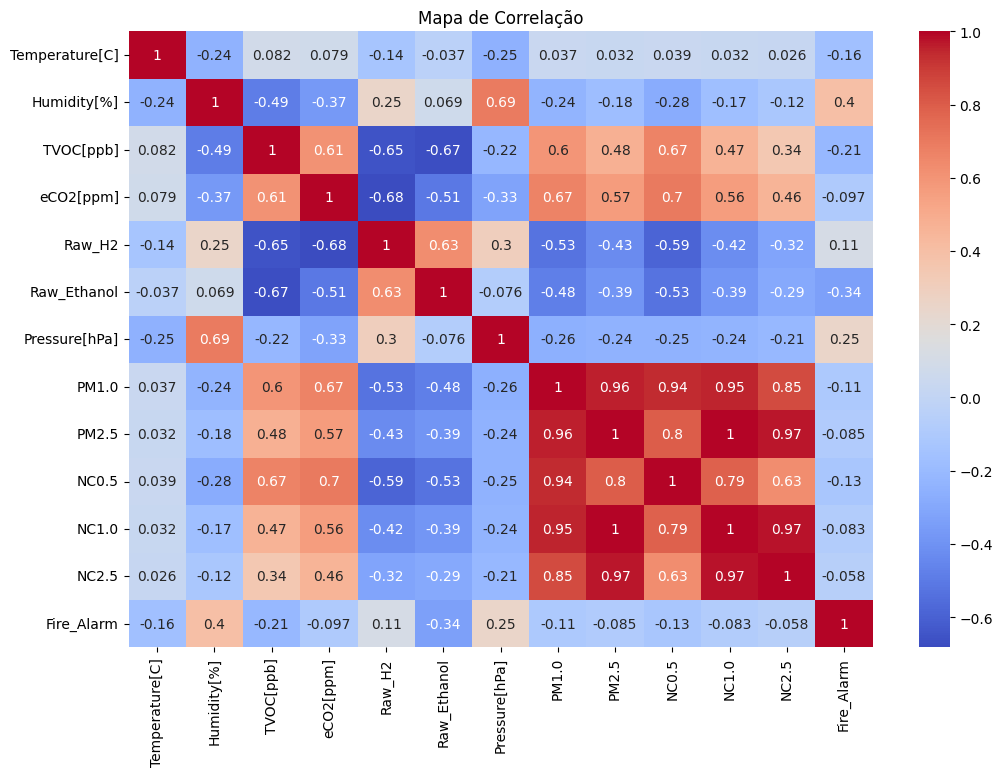

In [49]:
# Verificando correlação entre as variáveis

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Mapa de Correlação')
plt.show()

Obs: A análise de correlação mostrou que nenhuma variável isolada possui correlação linear muito alta com a variável alvo Fire_Alarm, embora Humidity[%] apresente relação moderada. Além disso, há forte correlação entre diversas variáveis, o que dá um direcionamento melhor para qual medelo será amais eficaz nessa situação.

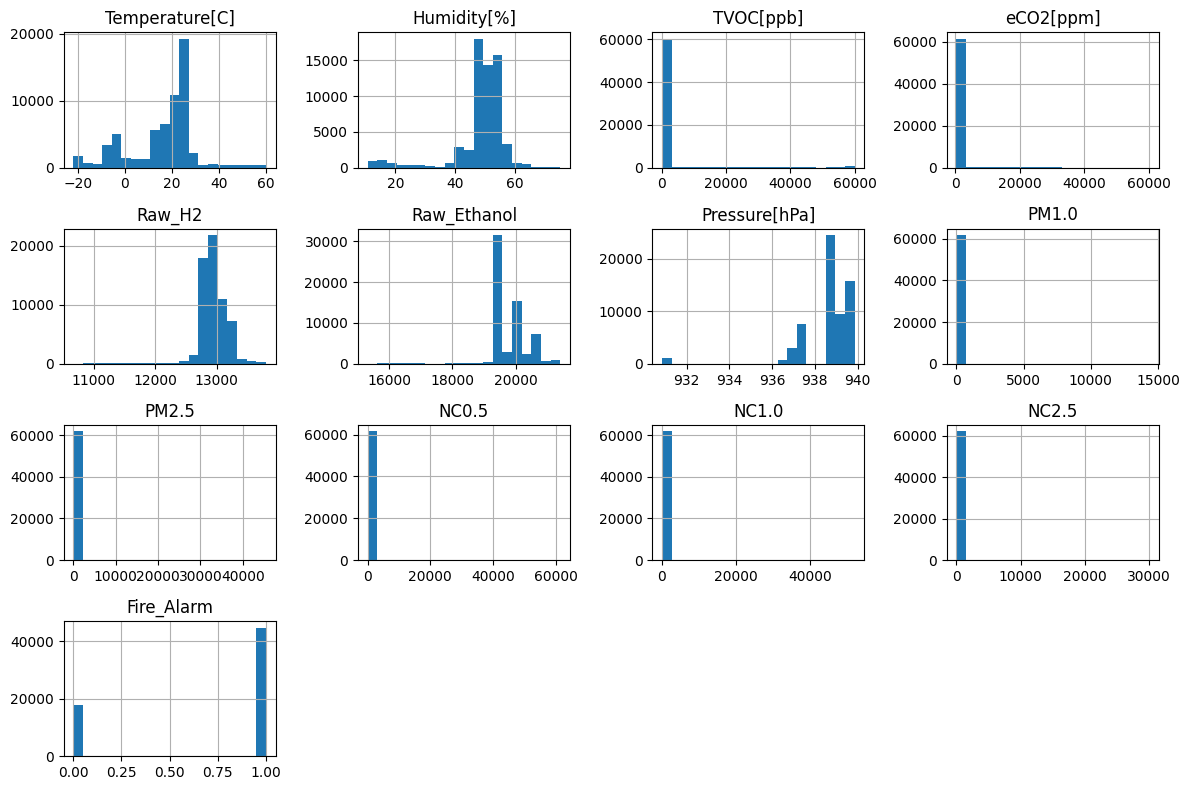

In [50]:
# Verifiacando Distribuição das varíaveis 

df.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

# 2 - Para essa base, onde você realizará as previsões de fire alarm, qual modelo de machine learning você aplicará? Justifique.




Resposta: O modelo que irei utilizar será o Random Forest. Fiz essa escolha porque ele se adapta bem a bases maiores e lida melhor com situações em que há muitas variáveis com forte correlação entre si, o que pode ser problemático para modelos mais sensíveis a esse tipo de relação, como a regressão logística. Além disso, a análise exploratória indicou que não há uma variável isolada com correlação extremamente alta com a variável alvo, o que sugere que o padrão pode ser mais complexo e não linear, favorecendo ainda mais o uso do Random Forest.

# 3 - Separe a base em Y e X e já rode a instância do modelo que você utilizará.

- Separando em X e y

In [51]:
# Separando

X = df.drop(columns='Fire_Alarm')
y = df['Fire_Alarm']

- Instanciando Modelo (Random Forest)

In [52]:
Modelo_RF = RandomForestClassifier(random_state=48, max_depth=12)

# 4 - Defina o número de Folds e rode o modelo com a validação cruzada.

- Definindo número de folds

In [53]:
folds = 5

- Rodando Modelo com validação cruzada (Cross Validation)

In [54]:
# Criando a instancia para fazer a validação cruzada

cv = KFold(n_splits = folds, shuffle=True, random_state=48)

# Rodando modelo

scores_acc = cross_val_score(Modelo_RF, X, y, cv=cv, scoring='accuracy')
scores_f1 = cross_val_score(Modelo_RF, X, y, cv=cv, scoring='f1')
scores_recall = cross_val_score(Modelo_RF, X, y, cv=cv, scoring='recall')


# 5 - Avalie a pontuação de cada modelo e ao final a validação final da média.

- Avaliando resultado

In [55]:
# Verificano acurácia

print("Accuracy por fold:", scores_acc)
print("Accuracy média:", scores_acc.mean())

# Verificando f1 Score

print("F1 por fold:", scores_f1)
print("F1 média:", scores_f1.mean())

# Verificando recall

print("Recall por fold:", scores_recall)
print("Recall média:", scores_recall.mean())

Accuracy por fold: [0.99984033 1.         1.         0.99984033 1.        ]
Accuracy média: 0.9999361328436851
F1 por fold: [0.9998885  1.         1.         0.99988836 1.        ]
F1 média: 0.9999553720652405
Recall por fold: [1.         1.         1.         0.99977674 1.        ]
Recall média: 0.9999553471757089


Obs.: Inicialmente, executei o Random Forest sem definir hiperparâmetros como max_depth, e o resultado foi uma acurácia extremamente próxima de 1, o que de fato levanta suspeitas e exige cautela na interpretação. Após limitar a profundidade máxima, o modelo continuou apresentando desempenho muito alto, o que pode indicar que existe um conjunto de variáveis que torna a separação entre as classes bastante clara para o modelo. Isso é positivo, mas também merece investigação adicional para confirmar que o desempenho está refletindo um padrão real e não apenas uma facilidade específica desta base.